### Simplified Attention Mechanism

In [1]:
import torch
print("Pytorch version:", torch.__version__)


Pytorch version: 2.10.0+cu126


In [2]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # your     x^1
     [0.55, 0.87, 0.66], # journey  x^2
     [0.57, 0.85, 0.64], # starts   x^3
     [0.22, 0.58, 0.33], # with     x^4
     [0.77, 0.25, 0.10], # one      x^5
     [0.05, 0.80, 0.55]] # step     x^6
)

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# corresponding words for the input vectors
words = ["your", "journey", "starts", "with", "one", "step"]

# extract x,y,z coordinates
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]
z_coords = inputs[:, 2]

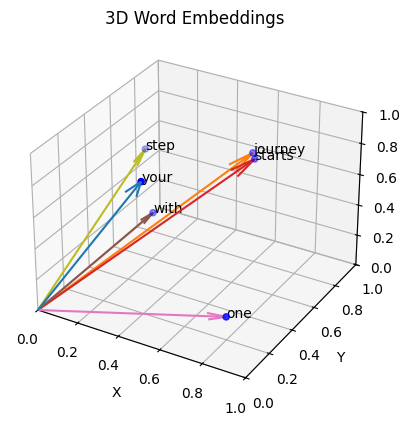

In [10]:
# 3d plot of Embedding with colored vectors
# arrow pointing from 0,0 to the point (x,y,z) for each word
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coords, y_coords, z_coords, c='blue', marker='o')
for i, word in enumerate(words):
    ax.text(x_coords[i], y_coords[i], z_coords[i], word)
for i in range(len(words)):
    ax.quiver(0, 0, 0, x_coords[i], y_coords[i], z_coords[i], 
              color=plt.cm.tab10(i / len(words)), 
              label=words[i], 
              arrow_length_ratio=0.1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Word Embeddings')
plt.show()

QUERY: The 2nd input token serves as the query

In [12]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print("Attention scores for query 'journey':", attn_scores_2)

Attention scores for query 'journey': tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


Now we normalize the attention scores , for better interpretability

if we add 0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865 > 1, hence we can't interpret them in Percentages

Main goal of NORMALIZATION is to obtain attention weights that sum up to 1

Useful for interpretation and maintaning training stability in an LLM

In [13]:
attn_weights_2_tmp = attn_scores_2 / torch.sum(attn_scores_2)
print("Attention weights for query 'journey':", attn_weights_2_tmp)
print("Sum of attention weights:", torch.sum(attn_weights_2_tmp))

Attention weights for query 'journey': tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum of attention weights: tensor(1.0000)


In Practice, it is more common to use SOFTMAX FUNCTION for normalization

This approach is better at managing extreme values and offers more favourable gradient properties

In [14]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

In [15]:
attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights (naive softmax) for query 'journey':", attn_weights_2_naive)
print("Sum of attention weights (naive softmax):", attn_weights_2_naive.sum())

Attention weights (naive softmax) for query 'journey': tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of attention weights (naive softmax): tensor(1.)


Softmax functions ensures that the attention weights are always positive.

This makes output interpretable as probabilities or relative importance.


Naive implementation may cause numerical instability such as Overflow or Underflow when dealing with very Large or Very Small values

In [16]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights (torch.softmax) for query 'journey':", attn_weights_2)
print("Sum of attention weights (torch.softmax):", attn_weights_2.sum())

Attention weights (torch.softmax) for query 'journey': tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of attention weights (torch.softmax): tensor(1.)
